<a href="https://colab.research.google.com/github/Ranveer2713/PBEl-GEN-AI/blob/main/Minor_projects_week_2_pynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project 1**: Student Placement Prediction
Objective

Predict whether a student will be Placed or Not Placed using classification algorithms.

Features:-

CGPA

Aptitude Score

Technical Skills

Communication Skills

Internship

Attendance

#Import Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

#Load Dataset

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/placement data.csv")

print(df.head())

   StudentID  CGPA  Internships  Projects  Workshops/Certifications  \
0          1   7.5            1         1                         1   
1          2   8.9            0         3                         2   
2          3   7.3            1         2                         2   
3          4   7.5            1         1                         2   
4          5   8.3            1         2                         2   

   AptitudeTestScore  SoftSkillsRating ExtracurricularActivities  \
0                 65               4.4                        No   
1                 90               4.0                       Yes   
2                 82               4.8                       Yes   
3                 85               4.4                       Yes   
4                 86               4.5                       Yes   

  PlacementTraining  SSC_Marks  HSC_Marks PlacementStatus  
0                No         61         79       NotPlaced  
1               Yes         78         82   

# Check dataset

In [ ]:
print(df.info())

print(df.describe())

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  10000 non-null  int64  
 1   CGPA                       10000 non-null  float64
 2   Internships                10000 non-null  int64  
 3   Projects                   10000 non-null  int64  
 4   Workshops/Certifications   10000 non-null  int64  
 5   AptitudeTestScore          10000 non-null  int64  
 6   SoftSkillsRating           10000 non-null  float64
 7   ExtracurricularActivities  10000 non-null  object 
 8   PlacementTraining          10000 non-null  object 
 9   SSC_Marks                  10000 non-null  int64  
 10  HSC_Marks                  10000 non-null  int64  
 11  PlacementStatus            10000 non-null  object 
dtypes: float64(2), int64(7), object(3)
memory usage: 937.6+ KB
None
         StudentID          CGPA   Inte

#Handle Missing Values

In [ ]:
df.dropna(inplace=True)

#Convert Categorical Data

In [ ]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

#Separate features and Target

In [ ]:
X = df.drop("PlacementStatus", axis=1)

y = df["PlacementStatus"]

#Split dataset

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

#Feature Scaling

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# **Logistic Regression**

In [ ]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_lr))

print(confusion_matrix(y_test, pred_lr))

print(classification_report(y_test, pred_lr))

Accuracy: 0.7935
[[953 219]
 [194 634]]
              precision    recall  f1-score   support

           0       0.83      0.81      0.82      1172
           1       0.74      0.77      0.75       828

    accuracy                           0.79      2000
   macro avg       0.79      0.79      0.79      2000
weighted avg       0.79      0.79      0.79      2000



# **Project 2**

#Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


#Load Dataset

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Loan Prediction.csv")

print("First 5 Rows:")
print(df.head())

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

First 5 Rows:
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001015   Male     Yes          0      Graduate            No   
1  LP001022   Male     Yes          1      Graduate            No   
2  LP001031   Male     Yes          2      Graduate            No   
3  LP001035   Male     Yes          2      Graduate            No   
4  LP001051   Male      No          0  Not Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5720                  0       110.0             360.0   
1             3076               1500       126.0             360.0   
2             5000               1800       208.0             360.0   
3             2340               2546       100.0             360.0   
4             3276                  0        78.0             360.0   

   Credit_History Property_Area  
0             1.0         Urban  
1             1.0         Urban  
2             1.0         Urban  
3       

#Handle Missing Values

In [ ]:
# Numerical columns
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    df[col].fillna(df[col].mean(), inplace=True)

# Categorical columns
cat_cols = df.select_dtypes(include=["object"]).columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())


Missing Values After Cleaning:
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64


/tmp/ipykernel_583/2735818008.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
/tmp/ipykernel_583/2735818008.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using

#Encode categorical columns

In [ ]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

print("\nEncoded Dataset:")
print(df.head())



Encoded Dataset:
   Loan_ID  Gender  Married  Dependents  Education  Self_Employed  \
0        0       1        1           0          0              0   
1        1       1        1           1          0              0   
2        2       1        1           2          0              0   
3        3       1        1           2          0              0   
4        4       1        0           0          1              0   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5720                  0       110.0             360.0   
1             3076               1500       126.0             360.0   
2             5000               1800       208.0             360.0   
3             2340               2546       100.0             360.0   
4             3276                  0        78.0             360.0   

   Credit_History  Property_Area  
0        1.000000              2  
1        1.000000              2  
2        1.000000              2  


# Separate Features & Target

In [ ]:
# Drop Loan_ID because it is just an identifier
if "Loan_ID" in df.columns:
    df.drop("Loan_ID", axis=1, inplace=True)


# Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# Feature Scaling

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Logistic Regression

In [ ]:
print("\n========== Logistic Regression ==========")

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

acc_lr = accuracy_score(y_test, pred_lr)

print("Accuracy:", acc_lr)

print("\nConfusion Matrix")
print(confusion_matrix(y_test, pred_lr))

print("\nClassification Report")
print(classification_report(y_test, pred_lr))


========== Logistic Regression ==========
Accuracy: 0.7935

Confusion Matrix
[[953 219]
 [194 634]]

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.81      0.82      1172
           1       0.74      0.77      0.75       828

    accuracy                           0.79      2000
   macro avg       0.79      0.79      0.79      2000
weighted avg       0.79      0.79      0.79      2000



# KNN

In [ ]:
print("\n========== KNN ==========")

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

pred_knn = knn.predict(X_test)

acc_knn = accuracy_score(y_test, pred_knn)

print("Accuracy:", acc_knn)

print("\nConfusion Matrix")
print(confusion_matrix(y_test, pred_knn))

print("\nClassification Report")
print(classification_report(y_test, pred_knn))



========== KNN ==========
Accuracy: 0.771

Confusion Matrix
[[950 222]
 [236 592]]

Classification Report
              precision    recall  f1-score   support

           0       0.80      0.81      0.81      1172
           1       0.73      0.71      0.72       828

    accuracy                           0.77      2000
   macro avg       0.76      0.76      0.76      2000
weighted avg       0.77      0.77      0.77      2000



# Decision Tree

In [ ]:
print("\n========== Decision Tree ==========")

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

acc_dt = accuracy_score(y_test, pred_dt)

print("Accuracy:", acc_dt)

print("\nConfusion Matrix")
print(confusion_matrix(y_test, pred_dt))

print("\nClassification Report")
print(classification_report(y_test, pred_dt))



========== Decision Tree ==========
Accuracy: 0.725

Confusion Matrix
[[894 278]
 [272 556]]

Classification Report
              precision    recall  f1-score   support

           0       0.77      0.76      0.76      1172
           1       0.67      0.67      0.67       828

    accuracy                           0.72      2000
   macro avg       0.72      0.72      0.72      2000
weighted avg       0.73      0.72      0.73      2000



# Random Forest

In [ ]:
print("\n========== Random Forest ==========")

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, pred_rf)

print("Accuracy:", acc_rf)

print("\nConfusion Matrix")
print(confusion_matrix(y_test, pred_rf))

print("\nClassification Report")
print(classification_report(y_test, pred_rf))



========== Random Forest ==========
Accuracy: 0.7935

Confusion Matrix
[[980 192]
 [221 607]]

Classification Report
              precision    recall  f1-score   support

           0       0.82      0.84      0.83      1172
           1       0.76      0.73      0.75       828

    accuracy                           0.79      2000
   macro avg       0.79      0.78      0.79      2000
weighted avg       0.79      0.79      0.79      2000



# Compare Results

In [ ]:
results = pd.DataFrame({
    "Algorithm": [
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        acc_lr,
        acc_knn,
        acc_dt,
        acc_rf
    ]
})

print("\n==============================")
print("Model Comparison")
print("==============================")
print(results)


Model Comparison
             Algorithm  Accuracy
0  Logistic Regression    0.7935
1                  KNN    0.7710
2        Decision Tree    0.7250
3        Random Forest    0.7935


# Plot Accuracy Comparison

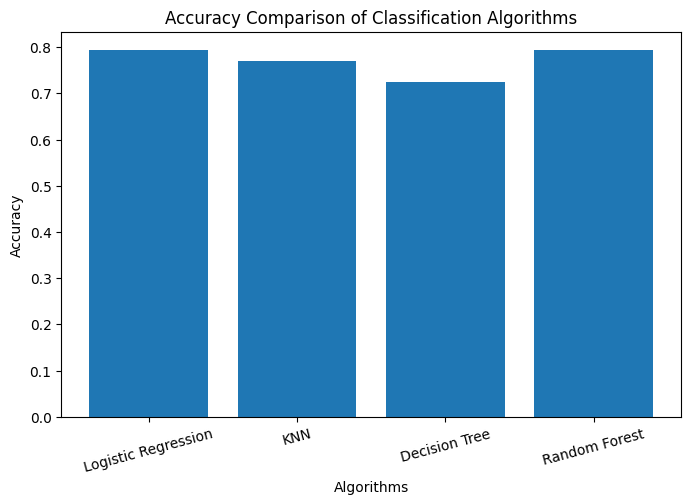

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(results["Algorithm"], results["Accuracy"])

plt.title("Accuracy Comparison of Classification Algorithms")

plt.xlabel("Algorithms")

plt.ylabel("Accuracy")

plt.xticks(rotation=15)

plt.show()

# Best Model

In [ ]:
best_model = results.loc[results["Accuracy"].idxmax()]

print("\nBest Model")
print("Algorithm :", best_model["Algorithm"])
print("Accuracy  :", best_model["Accuracy"])


Best Model
Algorithm : Logistic Regression
Accuracy  : 0.7935
